In [1]:
import torch
from ultralytics import YOLO
import glob
import os
from IPython.display import Image, display

In [2]:
# 1. Check core CUDA availability
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    # 2. Get the number of available GPUs
    print(f"GPU Count: {torch.cuda.device_count()}")
    
    # 3. Get the name of the current GPU
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    
    # 4. Get the current device index
    print(f"Current Device Index: {torch.cuda.current_device()}")


CUDA Available: True
GPU Count: 1
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU
Current Device Index: 0


In [3]:
def train_yolo_100_epochs_wsl():
    # 1. Hardware Verification
    print("=== Hardware & CUDA Verification ===")
    if not torch.cuda.is_available():
        print("CRITICAL: CUDA is not detected by PyTorch.")
        return
    
    print(f"CUDA Verified. Device: {torch.cuda.get_device_name(0)}")

    # 2. Initialize Model
    model = YOLO('yolo11n.pt') 

    # Explicit destination path inside project1
    project_dir = '/home/furinasimp/project1/runs/detect'

    # 3. Training Block (100 Epochs)
    print("\n=== Starting Phase 1: 100-Epoch GPU Training ===")
    results = model.train(
        data='Box Dataset/data.yaml',         
        epochs=100,                  
        imgsz=640,                   
        batch=8,                     
        device=0,                    
        workers=8,                   
        
        # --- Explicit Output Directory Control ---
        project=project_dir,         # Forces output destination to project1
        name='train_100ep',          # Specific subfolder name
        exist_ok=True,               # Overwrites 'train_100ep' instead of creating train9, train10...
        
        # --- Augmentation Parameters ---
        mosaic=1.0,                  
        mixup=0.2,                   
        degrees=15.0,                
        scale=0.5,                   
        translate=0.2,               
        perspective=0.0005,          
        hsv_h=0.015,                 
        hsv_s=0.7,                   
        hsv_v=0.4,                   
        erasing=0.4                  
    )

    print("\n=== Training Complete ===")
    print(f"Optimization weights saved to '{project_dir}/train_100ep/weights/best.pt'.")

if __name__ == '__main__':
    train_yolo_100_epochs_wsl()

=== Hardware & CUDA Verification ===
CUDA Verified. Device: NVIDIA GeForce RTX 4050 Laptop GPU

=== Starting Phase 1: 100-Epoch GPU Training ===
New https://pypi.org/project/ultralytics/8.4.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.116 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Box Dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, h

=== Selected Target Run: /home/furinasimp/project1/runs/detect/train_100ep ===
Target Weights File: /home/furinasimp/project1/runs/detect/train_100ep/weights/best.pt

=== Confusion Matrix ===


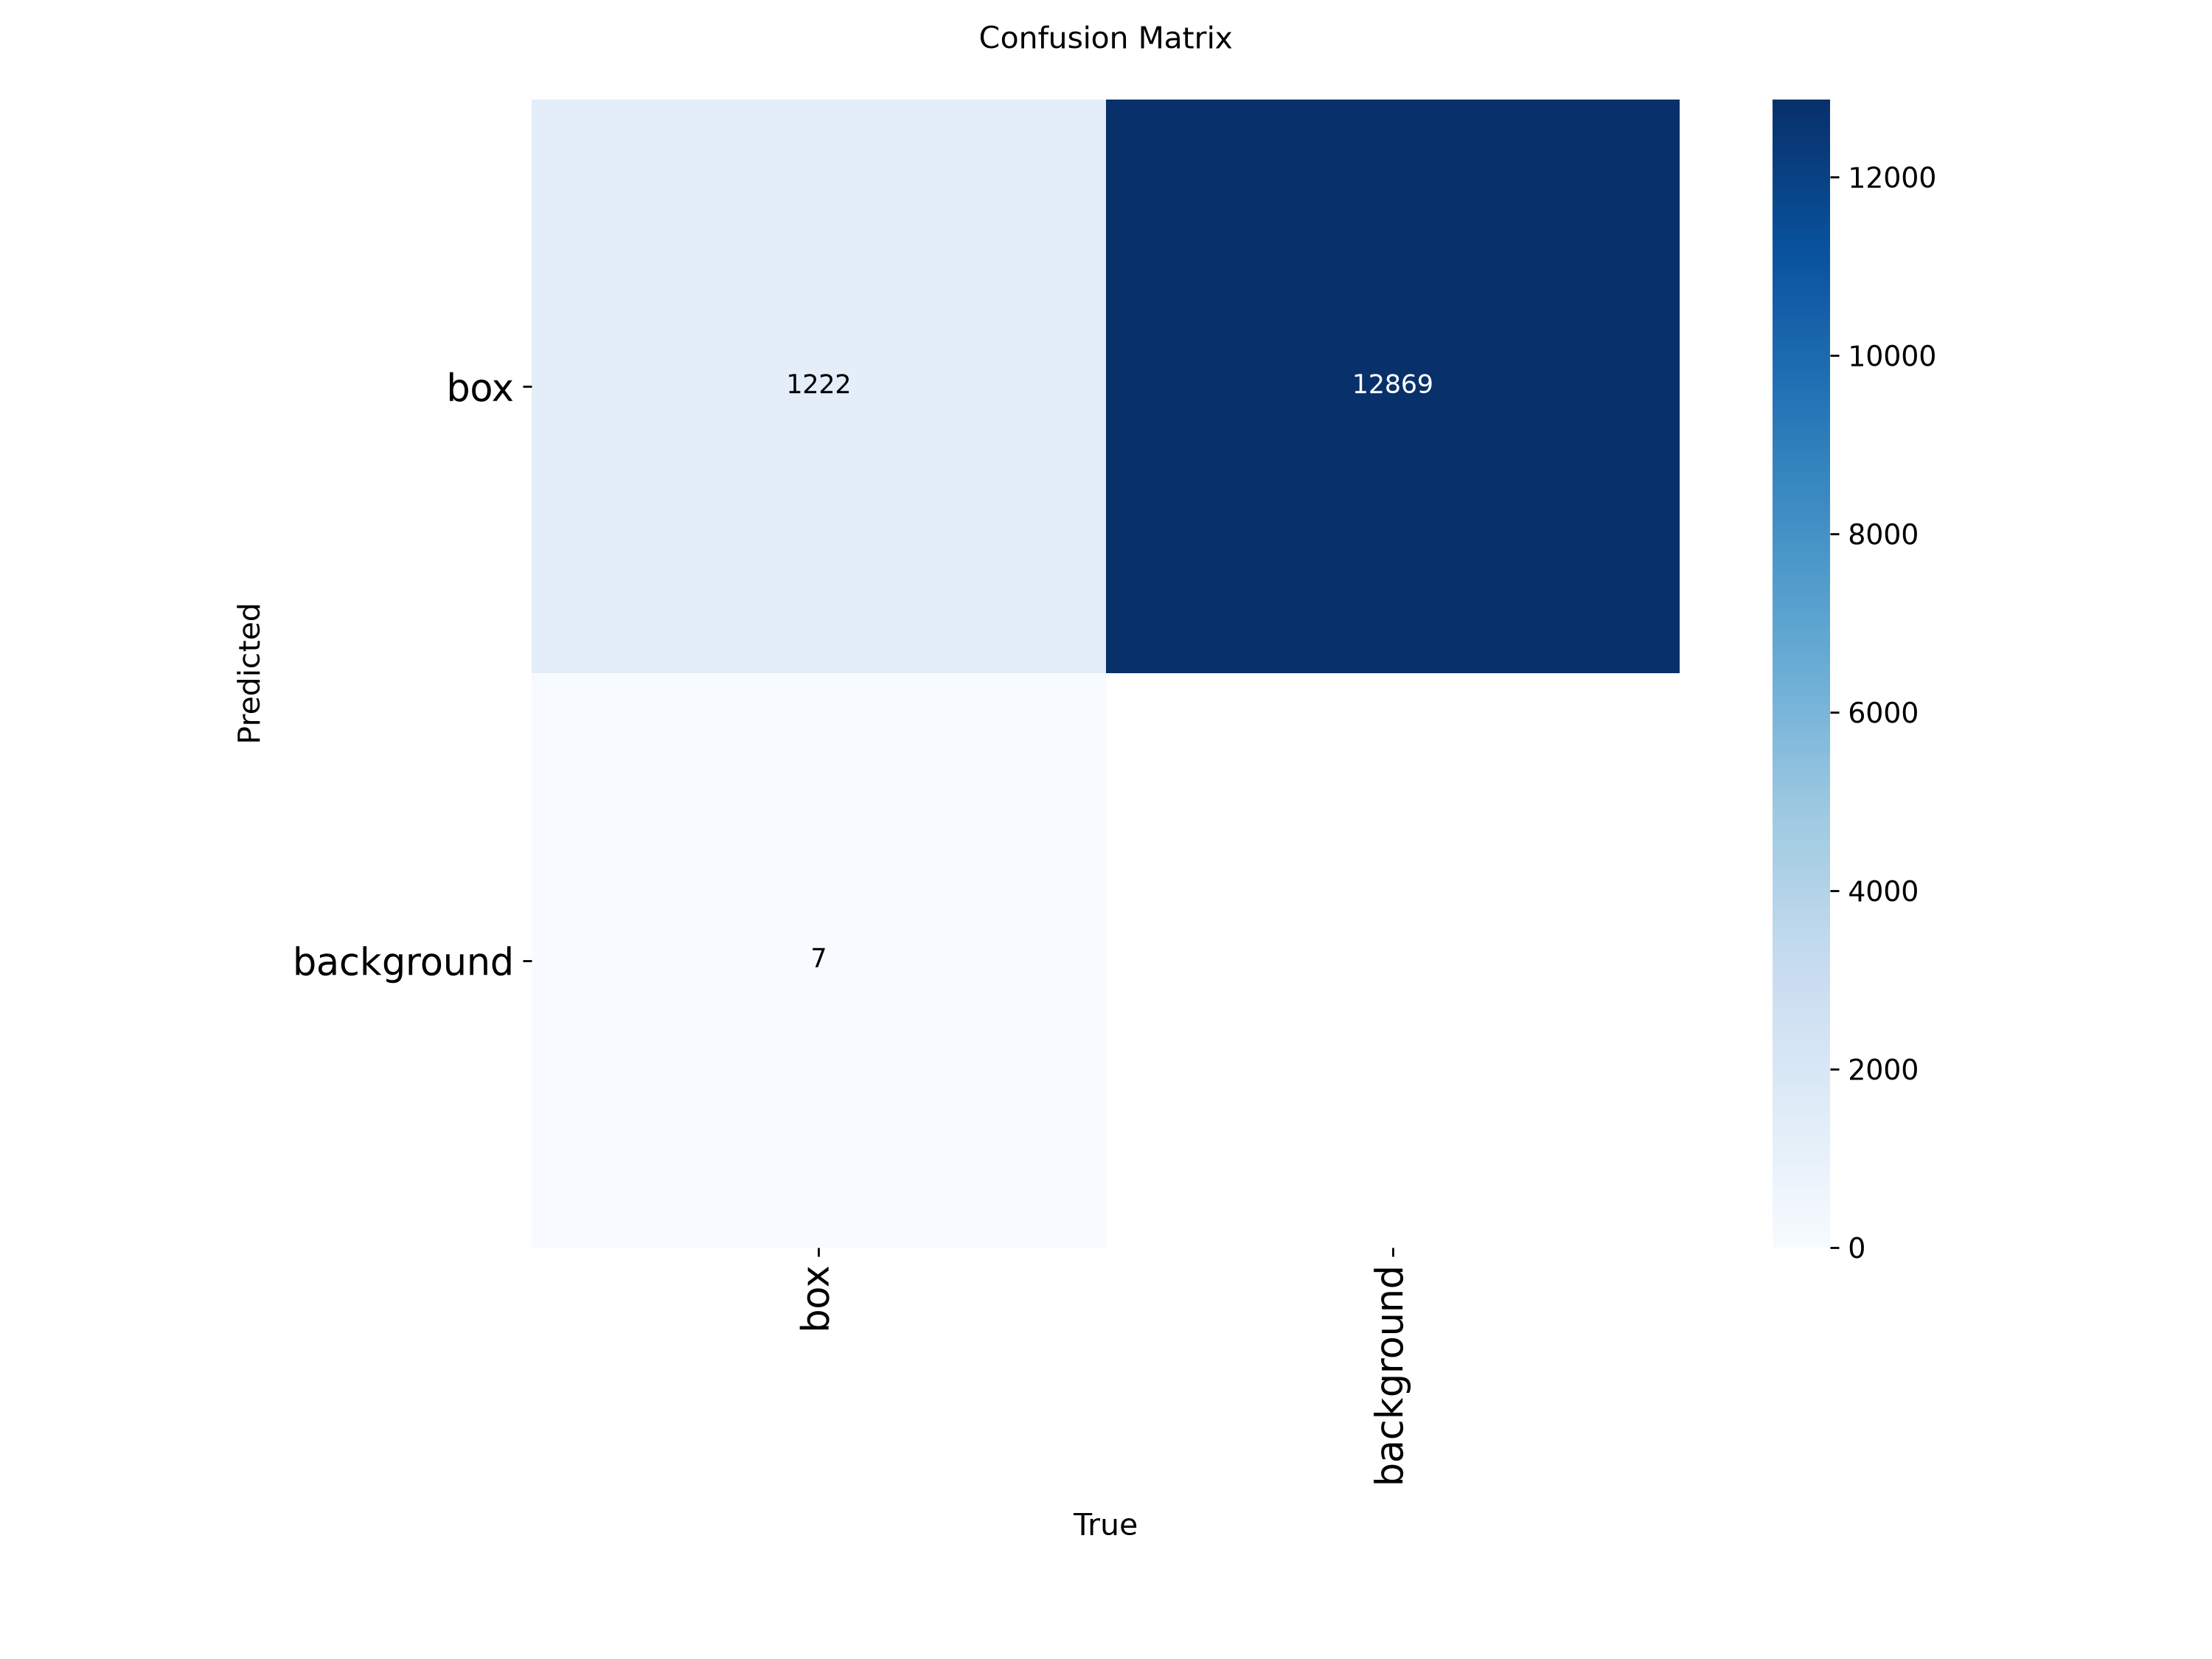


=== Training Loss & Metric Progression ===


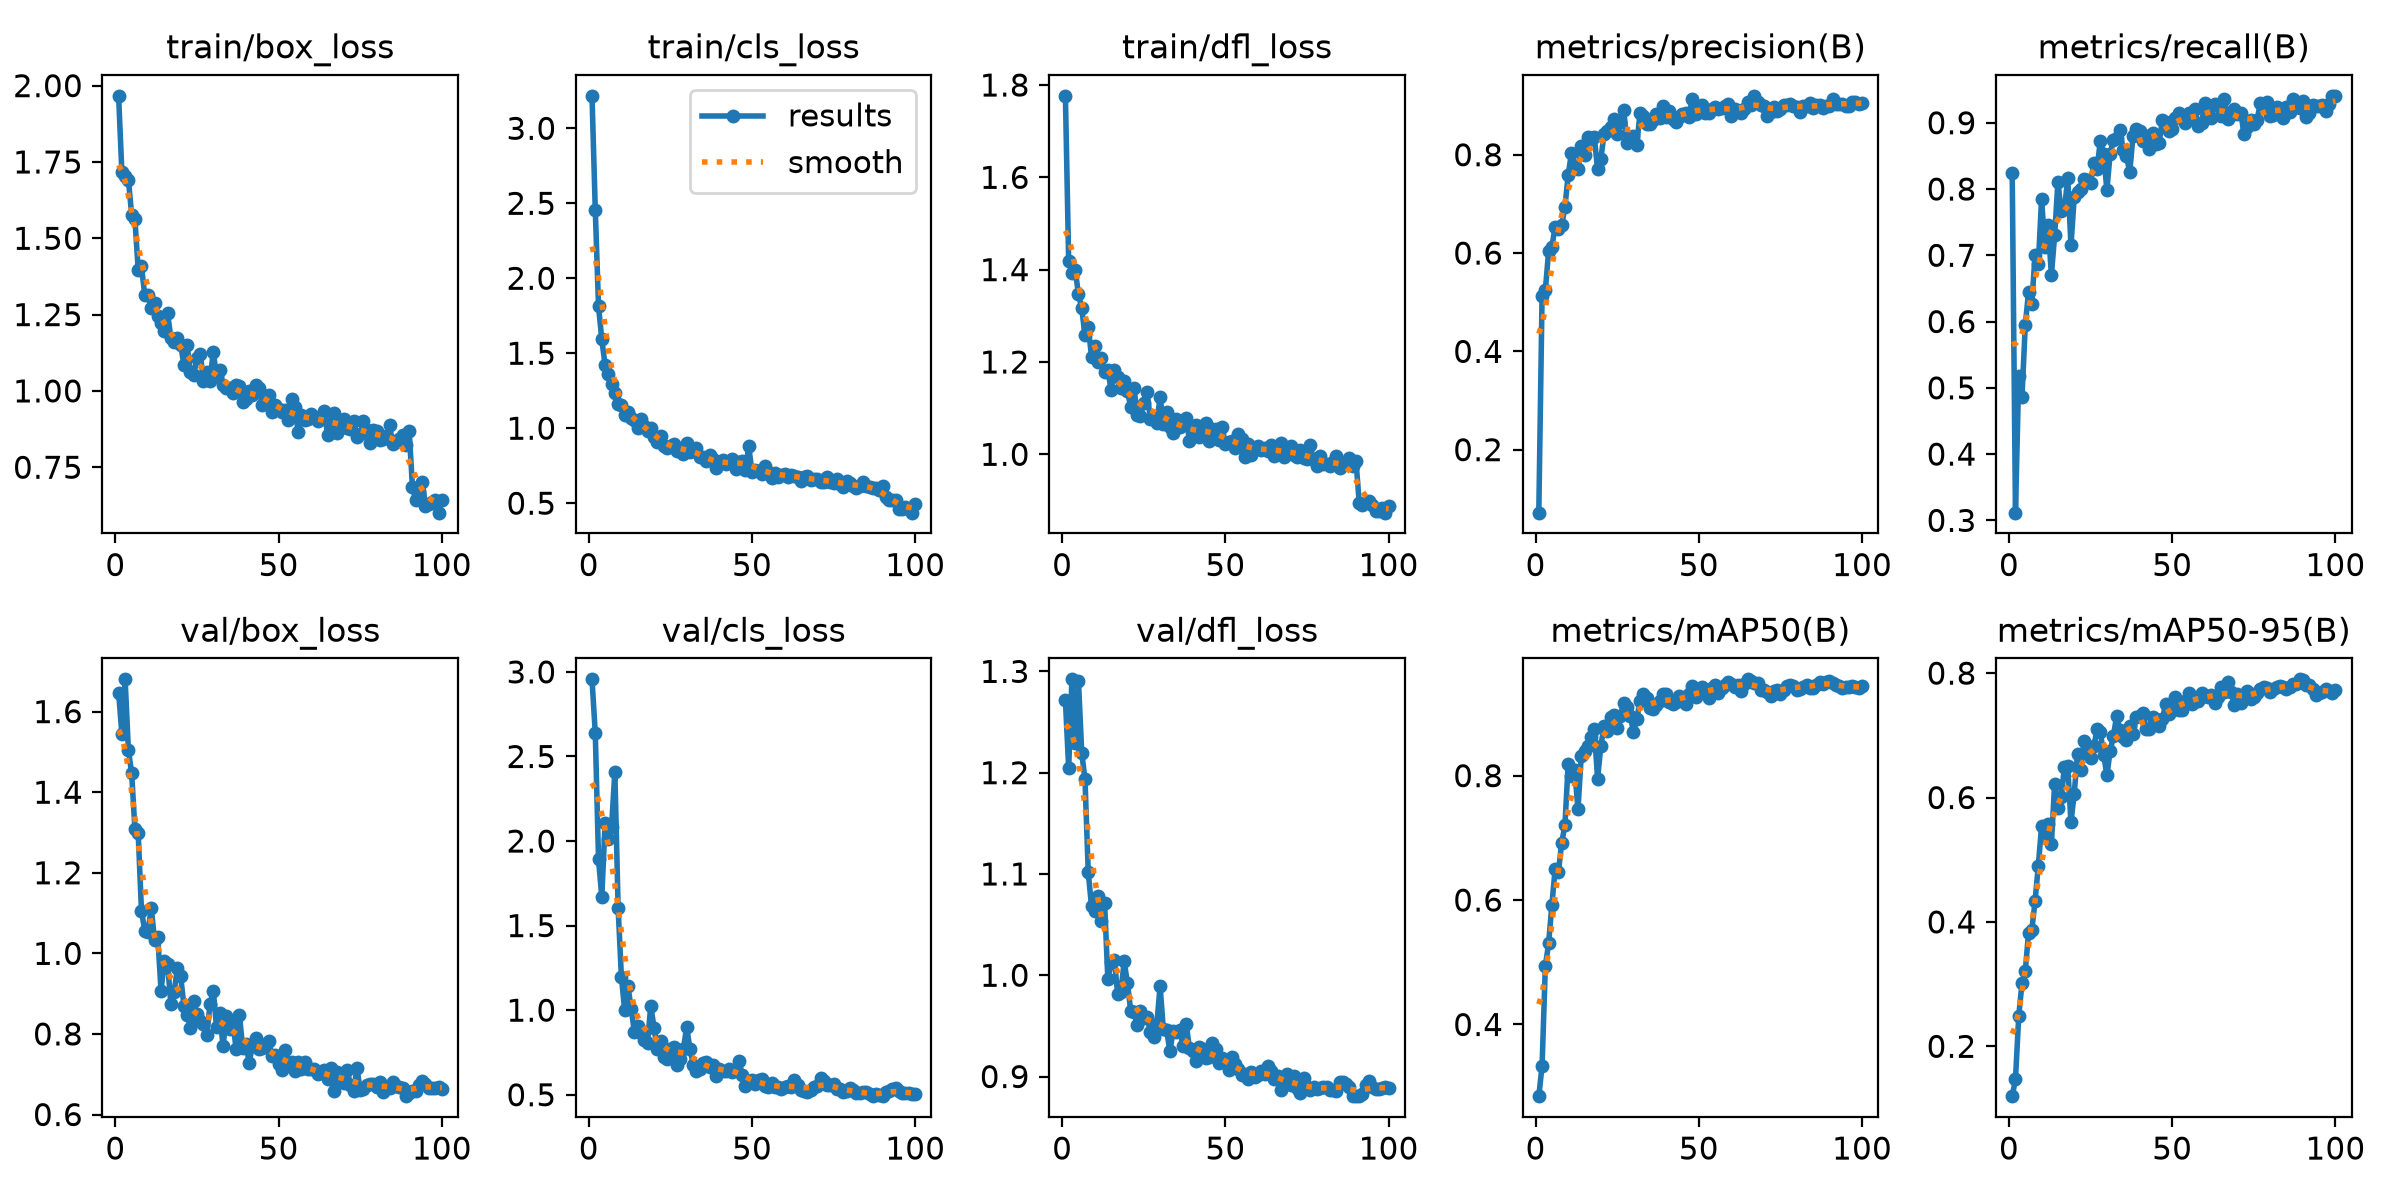


=== Executing Validation Pass ===
Ultralytics 8.4.116 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6141MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 476.4±94.2 MB/s, size: 1436.8 KB)
val: Scanning /home/furinasimp/project1/Box Dataset/valid/labels.cache... 99 images, 1 backgrounds, 52 corrupt: 100% ━━━━━━━━━━━━ 99/99 41.5Mit/s 0.0s
val: /home/furinasimp/project1/Box Dataset/valid/images/158_flight_1625_4302_png.rf.0b0e02cf25ddac7f9f022a3b945a65a5.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /home/furinasimp/project1/Box Dataset/valid/images/158_flight_1625_4316_png.rf.1979beae783b3fdd9b1873051a8ade83.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /home/furinasimp/project1/Box Dataset/valid/images/158_flight_1625_4322_png.rf.f

In [4]:
def evaluate_latest_valid_run():
    # Primary search path inside project1, with fallback to home dir
    primary_path = '/home/furinasimp/project1/runs/detect'
    fallback_path = '/home/furinasimp/runs/detect'
    
    search_paths = [primary_path, fallback_path]
    valid_runs = []

    for path in search_paths:
        if os.path.exists(path):
            for entry in os.listdir(path):
                full_run_path = os.path.join(path, entry)
                weights_path = os.path.join(full_run_path, 'weights', 'best.pt')
                if os.path.isfile(weights_path):
                    # Store tuple: (run_dir, weights_path, modification_time)
                    valid_runs.append((full_run_path, weights_path, os.path.getmtime(weights_path)))

    if not valid_runs:
        print("CRITICAL: No completed runs containing 'best.pt' were found.")
        return

    # Sort runs by modification time to automatically select the latest completed run
    valid_runs.sort(key=lambda x: x[2], reverse=True)
    latest_run_dir, latest_weights, _ = valid_runs[0]

    print(f"=== Selected Target Run: {latest_run_dir} ===")
    print(f"Target Weights File: {latest_weights}\n")

    # 1. Display Confusion Matrix
    cm_img = os.path.join(latest_run_dir, 'confusion_matrix.png')
    if os.path.exists(cm_img):
        print("=== Confusion Matrix ===")
        display(Image(filename=cm_img, width=800))

    # 2. Display Metric Curves
    results_img = os.path.join(latest_run_dir, 'results.png')
    if os.path.exists(results_img):
        print("\n=== Training Loss & Metric Progression ===")
        display(Image(filename=results_img, width=800))

    # 3. Quantitative Validation Pass
    print("\n=== Executing Validation Pass ===")
    model = YOLO(latest_weights)
    metrics = model.val()
    
    print("\n[VALIDATION METRICS]")
    print(f"Precision : {metrics.box.mp:.4f}")
    print(f"Recall    : {metrics.box.mr:.4f}")
    print(f"mAP@50    : {metrics.box.map50:.4f}")
    print(f"mAP@50-95 : {metrics.box.map:.4f}")

if __name__ == '__main__':
    evaluate_latest_valid_run()

In [5]:
def test_static_inference_wsl():
    # 1. Locate the latest valid weights
    target_weights = '/home/furinasimp/project1/runs/detect/train_100ep/weights/best.pt'
    
    if not os.path.exists(target_weights):
        # Fallback to scanning existing runs (e.g., train8)
        fallback_dir = '/home/furinasimp/runs/detect'
        if os.path.exists(fallback_dir):
            runs = [os.path.join(fallback_dir, d, 'weights', 'best.pt') for d in os.listdir(fallback_dir)]
            valid = [r for r in runs if os.path.exists(r)]
            if valid:
                valid.sort(key=os.path.getmtime, reverse=True)
                target_weights = valid[0]

    if not os.path.exists(target_weights):
        print("Error: No valid best.pt model weights found.")
        return

    print(f"Loading weights from: {target_weights}")
    model = YOLO(target_weights)

    # 2. Pick a test image from your validation directory
    val_images_path = '/home/furinasimp/project1/Box Dataset/valid/images/*.jpg'
    image_files = glob.glob(val_images_path)
    
    if not image_files:
        print("Error: No validation images found at specified path.")
        return
        
    sample_image = image_files[0]
    print(f"Running inference on: {sample_image}")

    # 3. Predict & Save Result
    output_project = '/home/furinasimp/project1/runs/detect'
    results = model.predict(
        source=sample_image, 
        conf=0.5, 
        save=True,
        project=output_project,
        name='predict_test',
        exist_ok=True
    )
    
    print(f"Inference complete. Annotated image saved to: {output_project}/predict_test/")

if __name__ == '__main__':
    test_static_inference_wsl()

Loading weights from: /home/furinasimp/project1/runs/detect/train_100ep/weights/best.pt
Running inference on: /home/furinasimp/project1/Box Dataset/valid/images/159_flight_1664_367_png.rf.74cc9fab430d1c1360aeb5a5bf28f01e.jpg

image 1/1 /home/furinasimp/project1/Box Dataset/valid/images/159_flight_1664_367_png.rf.74cc9fab430d1c1360aeb5a5bf28f01e.jpg: 384x640 19 boxs, 19.1ms
Speed: 2.9ms preprocess, 19.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /home/furinasimp/project1/runs/detect/predict_test
Inference complete. Annotated image saved to: /home/furinasimp/project1/runs/detect/predict_test/


In [15]:
import pandas as pd
import numpy as np

class LogisticsMockCatalog:
    def __init__(self, products_csv='/home/furinasimp/project1/olist dataset/olist_products_dataset.csv',
                 order_items_csv='/home/furinasimp/project1/olist dataset/olist_order_items_dataset.csv',
                 geo_csv='/home/furinasimp/project1/olist dataset/olist_geolocation_dataset.csv'):
        
        print("=== Initializing Logistics Mock Catalog ===")
        self.catalog = self._build_pipeline(products_csv, order_items_csv, geo_csv)
        self._split_pools()

    def _build_pipeline(self, products_csv, order_items_csv, geo_csv):
        print("Loading datasets into memory...")
        products = pd.read_csv(products_csv)
        order_items = pd.read_csv(order_items_csv)
        geo = pd.read_csv(geo_csv)

        df = pd.merge(order_items, products, on='product_id', how='inner')

        print("Cleaning hidden anomalies and zero-values...")
        critical_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
        
        for col in critical_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df = df.dropna(subset=critical_cols)

        df = df[(df['product_weight_g'] > 0) & 
                (df['product_length_cm'] > 0) & 
                (df['product_height_cm'] > 0) & 
                (df['product_width_cm'] > 0)]

        df['weight_kg'] = df['product_weight_g'] / 1000.0
        df['volume_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

        print("Mapping mock delivery coordinates...")
        unique_coords = geo[['geolocation_lat', 'geolocation_lng']].drop_duplicates().values
        
        np.random.seed(42) 
        random_geo_indices = np.random.randint(0, len(unique_coords), size=len(df))
        
        df['delivery_lat'] = unique_coords[random_geo_indices, 0]
        df['delivery_lon'] = unique_coords[random_geo_indices, 1]

        return df[['product_id', 'weight_kg', 'volume_cm3', 'delivery_lat', 'delivery_lon']]

    def _split_pools(self):
        mask_small = (self.catalog['volume_cm3'] < 10000) & (self.catalog['weight_kg'] < 5.0)
        self.small_items = self.catalog[mask_small]
        self.large_items = self.catalog[~mask_small]
        
        print(f"Catalog successfully built: {len(self.small_items)} Small items | {len(self.large_items)} Large items.")

    def get_item_metadata(self, cv_class_id):
        if cv_class_id == 0:
            pool = self.small_items
        elif cv_class_id == 1:
            pool = self.large_items
        else:
            raise ValueError("Invalid cv_class_id. Supported classes: 0 (Small), 1 (Large).")

        if pool.empty:
            raise RuntimeError(f"Data pool for class {cv_class_id} is exhausted or empty.")

        sampled_row = pool.sample(n=1).iloc[0]
        
        return {
            "weight_kg": round(sampled_row['weight_kg'], 3),
            "volume_cm3": round(sampled_row['volume_cm3'], 2),
            "delivery_lat": round(sampled_row['delivery_lat'], 6),
            "delivery_lon": round(sampled_row['delivery_lon'], 6)
        }

# === Execution & Testing Block ===
try:
    catalog = LogisticsMockCatalog()
    
    print("\n=== Testing Lookup Function ===")
    small_box = catalog.get_item_metadata(cv_class_id=0)
    print(f"Detected Class 0 (Small Box):\n  - Weight: {small_box['weight_kg']} kg\n  - Volume: {small_box['volume_cm3']} cm³")

    large_box = catalog.get_item_metadata(cv_class_id=1)
    print(f"\nDetected Class 1 (Large Box):\n  - Weight: {large_box['weight_kg']} kg\n  - Volume: {large_box['volume_cm3']} cm³")

except FileNotFoundError:
    print("\nTest bypassed: Olist datasets not found in the current directory.")

=== Initializing Logistics Mock Catalog ===
Loading datasets into memory...
Cleaning hidden anomalies and zero-values...
Mapping mock delivery coordinates...
Catalog successfully built: 67825 Small items | 44799 Large items.

=== Testing Lookup Function ===
Detected Class 0 (Small Box):
  - Weight: 0.71 kg
  - Volume: 3458.0 cm³

Detected Class 1 (Large Box):
  - Weight: 6.55 kg
  - Volume: 8000.0 cm³


In [17]:
import math
import requests
import time
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

class ExactFuelRouter:
    def __init__(self, coords, weights_kg, volumes_cm3, vehicle_max_vol=1000000):
        self.coords = coords
        self.weights = weights_kg
        self.volumes = volumes_cm3
        self.vehicle_max_vol = vehicle_max_vol
        self.num_nodes = len(coords)
        self.dist_matrix = self._get_osrm_matrix()

    def _get_osrm_matrix(self):
        coords_str = ";".join(self.coords)
        url = f"http://router.project-osrm.org/table/v1/driving/{coords_str}?annotations=distance"
        try:
            response = requests.get(url, timeout=5)
            response.raise_for_status()
            data = response.json()
            if 'distances' in data:
                return data['distances']
        except Exception:
            pass
        return self._generate_fallback_matrix()

    def _generate_fallback_matrix(self):
        matrix = []
        points = [tuple(map(float, c.split(','))) for c in self.coords]
        for lon1, lat1 in points:
            row = []
            for lon2, lat2 in points:
                R, phi1, phi2 = 6371000, math.radians(lat1), math.radians(lat2)
                dphi, dlambda = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
                a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
                row.append(R * (2 * math.atan2(math.sqrt(a), math.sqrt(1-a))) * 1.5) 
            matrix.append(row)
        return matrix

    def calculate_fuel(self, route):
        total_fuel, current_payload = 0.0, sum(self.weights[n] for n in route)
        for i in range(len(route) - 1):
            u, v = route[i], route[i+1]
            if u != 0: current_payload -= self.weights[u] 
            dist_km = self.dist_matrix[u][v] / 1000.0
            total_fuel += dist_km * (0.3 + 0.00005 * current_payload)
        return total_fuel

    def solve_greedy(self):
        unvisited, route, curr = list(range(1, self.num_nodes)), [0], 0
        while unvisited:
            next_node = min(unvisited, key=lambda x: self.dist_matrix[curr][x])
            route.append(next_node)
            unvisited.remove(next_node)
            curr = next_node
        route.append(0)
        return route

    def solve_exact_fuel(self):
        manager = pywrapcp.RoutingIndexManager(self.num_nodes, 1, 0)
        routing = pywrapcp.RoutingModel(manager)

        # 1. Base Travel Cost (Scaled by 30,000 for integer precision)
        def dist_callback(from_idx, to_idx):
            dist_m = int(self.dist_matrix[manager.IndexToNode(from_idx)][manager.IndexToNode(to_idx)])
            return dist_m * 30000
            
        transit_idx = routing.RegisterTransitCallback(dist_callback)
        routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

        # We must also track actual unscaled distance for the penalty multiplier
        def raw_dist_callback(from_idx, to_idx):
            return int(self.dist_matrix[manager.IndexToNode(from_idx)][manager.IndexToNode(to_idx)])
        
        raw_transit_idx = routing.RegisterTransitCallback(raw_dist_callback)
        routing.AddDimension(raw_transit_idx, 0, 3000000, True, "RawDistance")
        raw_dist_dim = routing.GetDimensionOrDie("RawDistance")

        # 2. Payload Penalty (Scaled by 5 for integer precision)
        for i in range(1, self.num_nodes):
            weight_penalty_coefficient = int(self.weights[i] * 5)
            raw_dist_dim.SetCumulVarSoftUpperBound(manager.NodeToIndex(i), 0, weight_penalty_coefficient)

        # 3. Volumetric Capacity
        def vol_callback(from_idx): return int(self.volumes[manager.IndexToNode(from_idx)])
        vol_idx = routing.RegisterUnaryTransitCallback(vol_callback)
        routing.AddDimension(vol_idx, 0, self.vehicle_max_vol, True, "Volume")

        search_params = pywrapcp.DefaultRoutingSearchParameters()
        search_params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
        search_params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
        search_params.time_limit.seconds = 1

        solution = routing.SolveWithParameters(search_params)
        if not solution: return []
        
        index = routing.Start(0)
        route_arr = []
        while not routing.IsEnd(index):
            route_arr.append(manager.IndexToNode(index))
            index = solution.Value(routing.NextVar(index))
        route_arr.append(manager.IndexToNode(index))
        return route_arr

def run_scenarios():
    scenarios = {
        "Scenario 1: The Tangerang Outlier (Whale)": {
            "coords": ["106.7983,-6.2625", "106.8000,-6.2650", "106.8050,-6.2700", "106.8100,-6.2750", "106.8150,-6.2800", "106.6288,-6.1783"],
            "weights": [0, 15, 20, 10, 15, 800],
            "volumes": [0, 10000, 10000, 10000, 10000, 400000]
        },
        "Scenario 2: Balanced Urban Run (No Whale)": {
            "coords": ["106.8200,-6.1800", "106.8250,-6.1700", "106.8300,-6.1600", "106.8100,-6.1750", "106.8000,-6.1650", "106.8150,-6.1500"],
            "weights": [0, 40, 35, 50, 45, 30],
            "volumes": [0, 20000, 20000, 20000, 20000, 20000]
        },
        "Scenario 3: Bekasi Industrial Corridor (Whale)": {
            "coords": ["107.0673,-6.2642", "107.0984,-6.2676", "107.1472,-6.3006", "107.1800,-6.3200", "107.2500,-6.3000", "106.9500,-6.1500"],
            "weights": [0, 10, 15, 20, 10, 850],
            "volumes": [0, 15000, 15000, 15000, 15000, 450000]
        },
        "Scenario 4: Split Load (Two Medium Whales)": {
            "coords": ["106.8900,-6.1500", "106.8800,-6.1400", "106.8500,-6.1300", "106.8000,-6.1200", "106.7500,-6.1100", "106.9500,-6.1600"],
            "weights": [0, 400, 10, 15, 350, 20],
            "volumes": [0, 300000, 10000, 10000, 300000, 10000]
        },
        "Scenario 5: Suburban Sprawl (No Whale)": {
            "coords": ["106.7410,-6.1873", "106.7300,-6.1500", "106.7000,-6.1400", "106.6500,-6.2500", "106.6800,-6.2800", "106.6200,-6.2200"],
            "weights": [0, 25, 30, 20, 40, 15],
            "volumes": [0, 15000, 15000, 15000, 15000, 15000]
        }
    }

    print("=== EXECUTING 5 ROUTING SCENARIOS (EXACT FUEL OPTIMIZATION) ===")
    for name, data in scenarios.items():
        print(f"\n--- {name} ---")
        router = ExactFuelRouter(data["coords"], data["weights"], data["volumes"])
        
        std_route = router.solve_greedy()
        opt_route = router.solve_exact_fuel()
        
        if not opt_route:
            print("Solver Failed: Capacity limits exceeded.")
            continue

        std_fuel = router.calculate_fuel(std_route)
        opt_fuel = router.calculate_fuel(opt_route)
        savings = ((std_fuel - opt_fuel) / std_fuel) * 100 if std_fuel > 0 else 0
        
        print(f"Standard Route   : {' -> '.join(map(str, std_route))}")
        print(f"Optimized Route  : {' -> '.join(map(str, opt_route))}")
        print(f"Fuel Saved       : {savings:.2f}%")
        print(f"LIFO Instructions: {opt_route[1:-1][::-1]}")
        
        time.sleep(1.5) 

if __name__ == "__main__":
    run_scenarios()

=== EXECUTING 5 ROUTING SCENARIOS (EXACT FUEL OPTIMIZATION) ===

--- Scenario 1: The Tangerang Outlier (Whale) ---
Standard Route   : 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 0
Optimized Route  : 0 -> 5 -> 1 -> 2 -> 4 -> 3 -> 0
Fuel Saved       : 1.82%
LIFO Instructions: [3, 4, 2, 1, 5]

--- Scenario 2: Balanced Urban Run (No Whale) ---
Standard Route   : 0 -> 3 -> 1 -> 5 -> 2 -> 4 -> 0
Optimized Route  : 0 -> 3 -> 4 -> 5 -> 2 -> 1 -> 0
Fuel Saved       : 20.19%
LIFO Instructions: [1, 2, 5, 4, 3]

--- Scenario 3: Bekasi Industrial Corridor (Whale) ---
Standard Route   : 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 0
Optimized Route  : 0 -> 5 -> 1 -> 3 -> 4 -> 2 -> 0
Fuel Saved       : 12.09%
LIFO Instructions: [2, 4, 3, 1, 5]

--- Scenario 4: Split Load (Two Medium Whales) ---
Standard Route   : 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 0
Optimized Route  : 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 0
Fuel Saved       : 0.00%
LIFO Instructions: [5, 4, 3, 2, 1]

--- Scenario 5: Suburban Sprawl (No Whale) ---
Standard Route   : 0 -> 1 ->